# 04 - Estimation

The specification was fixed in notebook 03 before any treatment effect was computed:

| choice | value | reason |
|---|---|---|
| outcome | log first-years by study location | state sizes differ 20-fold |
| window | 1998-2007 | ends before the first abolition, so treatment is absorbing |
| comparison group | all 9 never-treated states | best power (MDE 5.5%) |
| inference | clustered by state **and** wild cluster bootstrap | only 16 clusters |

**Pre-committed in notebook 03:** the minimum detectable effect is about 5.5%. A null result
is therefore uninformative for effects below that and will be reported as such, not as
evidence of no effect.

The estimators form a hierarchy (`DESIGN.md` 8), each fixing a specific failure of the one
above.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import estimation as est
FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

WINDOW_END = 2007
OUTCOME    = "log_fy"
MDE_PCT    = 5.5          # from notebook 03

panel = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
panel[OUTCOME] = np.log(panel["first_years_location"])
d = panel[panel.year <= WINDOW_END].copy()

# numeric cluster id: the wild bootstrap runs through numba and cannot take a
# string cluster variable
d["state_id"] = d["state_code"].astype("category").cat.codes.astype("int64")

print(f"estimation window {d.year.min()}-{d.year.max()} | {len(d)} rows | "
      f"{d.state.nunique()} states")
print(f"treated states: {d[d.ever_treated==1].state.nunique()}, "
      f"never-treated: {d[d.ever_treated==0].state.nunique()}")
print(f"post-treatment periods: {sorted(d.loc[d.treated==1,'year'].unique())}")

estimation window 1998-2007 | 160 rows | 16 states
treated states: 7, never-treated: 9
post-treatment periods: [np.int32(2006), np.int32(2007)]


## Layer 1: two-way fixed effects

The textbook baseline, reported and then critiqued. Coefficients on a logged outcome are
approximate proportional effects; the exact percentage is `exp(b) - 1`.

In [2]:
twfe = pf.feols(f"{OUTCOME} ~ treated | state_id + year", data=d,
                vcov={"CRV1": "state_id"})
print(twfe.summary())

t = twfe.tidy().loc["treated"]
b, se = t["Estimate"], t["Std. Error"]
print(f"\npoint estimate: {100*(np.exp(b)-1):+.2f}%   "
      f"(log coef {b:+.4f}, clustered se {se:.4f})")
print(f"95% CI        : {100*(np.exp(b-1.96*se)-1):+.2f}% to {100*(np.exp(b+1.96*se)-1):+.2f}%")

###

Estimation:  OLS
Dep. var.: log_fy, Fixed effects: state_id + year
sample: None = all
Inference:  CRV1
Observations:  160

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treated       |     -0.050 |        0.020 |    -2.450 |      0.027 | -0.094 |  -0.007 |
---
RMSE: 0.046 R2: 0.997 R2 Within: 0.035 
None

point estimate: -4.89%   (log coef -0.0502, clustered se 0.0205)
95% CI        : -8.64% to -1.00%


### Where does the identifying variation come from?

With state and year fixed effects, the treated indicator is identified only from
*within-year* variation. This check confirms that treated and untreated states coexist in
the post-treatment periods, which is what a never-treated comparison group provides.

In [3]:
var = d.groupby("year")["treated"].agg(treated_share="mean", n_distinct="nunique")
print("n_distinct == 1 means that year contributes no identifying variation:\n")
print(var.to_string())

n_distinct == 1 means that year contributes no identifying variation:

      treated_share  n_distinct
year                           
1998         0.0000           1
1999         0.0000           1
2000         0.0000           1
2001         0.0000           1
2002         0.0000           1
2003         0.0000           1
2004         0.0000           1
2005         0.0000           1
2006         0.1250           2
2007         0.4375           2


## Inference with 16 clusters

Cluster-robust standard errors are asymptotic in the number of clusters. With 16 states the
approximation is unreliable and tends to **understate** uncertainty. The wild cluster
bootstrap (Cameron, Gelbach and Miller) is the standard correction. It is expected to widen
the interval, and that is the point: an honest interval beats a falsely precise one.

In [4]:
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        wb = twfe.wildboottest(param="treated", reps=9999, seed=42)
    p_wild = float(wb["Pr(>|t|)"])
    print(wb)
except Exception as exc:
    p_wild = np.nan
    print("wild bootstrap unavailable:", type(exc).__name__, exc)
    print("install with: pip install wildboottest")

print(f"\nanalytic clustered p-value : {t['Pr(>|t|)']:.4f}")
if not np.isnan(p_wild):
    print(f"wild bootstrap p-value     : {p_wild:.4f}")
    ratio = p_wild / t["Pr(>|t|)"] if t["Pr(>|t|)"] > 0 else np.nan
    print(f"ratio                      : {ratio:.2f}x")
    print("\nA bootstrap p-value materially larger than the analytic one means the"
          "\nclustered standard errors were understating uncertainty.")

param                         treated
t value            -2.323577857864275
Pr(>|t|)          0.06510651065106511
bootstrap_type                     11
inference               CRV(state_id)
impose_null                      True
ssc                          1.265672
dtype: object

analytic clustered p-value : 0.0270
wild bootstrap p-value     : 0.0651
ratio                      : 2.41x

A bootstrap p-value materially larger than the analytic one means the
clustered standard errors were understating uncertainty.


## Layer 2: Callaway and Sant'Anna

The primary estimator. Each treated cohort is compared only against **never-treated** states,
avoiding the forbidden comparisons that bias TWFE under staggered adoption. The window ends
before the first abolition so treatment is absorbing, which the estimator requires
(`DESIGN.md` 2).

In [5]:
# estimator mechanics live in src/estimation.py; this notebook picks the
# specification and reads the output (DESIGN.md design rule)
run_cs  = lambda df, label="", **kw: est.callaway_santanna(df, OUTCOME, **kw)
flatten = est.tidy_att

# differences expects NaN (not 0) for never-treated units
d["treatment_year_cs"] = d["intro_year"].astype("float")

att = run_cs(d, "baseline")
overall = flatten(att.aggregate("simple"))
print("Callaway-Sant'Anna, overall ATT (log points):")
print(overall.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

cs_b, cs_se = overall["ATT"].iloc[0], overall["SE"].iloc[0]
print(f"\nas a percentage: {100*(np.exp(cs_b)-1):+.2f}%  "
      f"[{100*(np.exp(overall['lo'].iloc[0])-1):+.2f}%, "
      f"{100*(np.exp(overall['hi'].iloc[0])-1):+.2f}%]")

Callaway-Sant'Anna, overall ATT (log points):
      ATT        SE        lo        hi
  -0.0649    0.0180   -0.1002   -0.0295

as a percentage: -6.28%  [-9.54%, -2.91%]


## Layer 3: event study

Relative-period effects. Periods before 0 are placebos and test the parallel-trends
assumption; periods 0 and later are the treatment response.

**Expect a lopsided picture.** The window gives up to nine pre-periods but only two
post-periods, because it must end before the first abolition.

Period -1 is also worth watching on its own: Hessen fell 5.2% the semester fees were
*announced* rather than charged (notebook 02), so a negative lead at -1 would indicate
anticipation rather than a violated assumption.

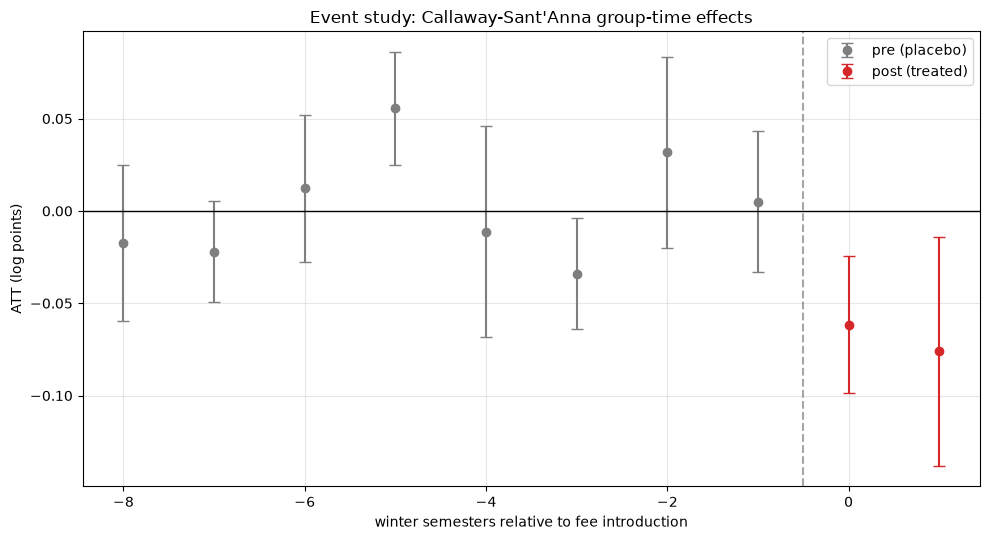

 rel       ATT        SE        lo        hi       pct
  -8   -0.0175    0.0216   -0.0597    0.0248   -1.7335
  -7   -0.0221    0.0139   -0.0494    0.0052   -2.1847
  -6    0.0122    0.0202   -0.0274    0.0518    1.2272
  -5    0.0556    0.0156    0.0250    0.0861    5.7141
  -4   -0.0112    0.0292   -0.0684    0.0459   -1.1180
  -3   -0.0341    0.0154   -0.0642   -0.0040   -3.3514
  -2    0.0317    0.0264   -0.0199    0.0834    3.2246
  -1    0.0051    0.0195   -0.0331    0.0432    0.5078
   0   -0.0617    0.0189   -0.0988   -0.0246   -5.9806
   1   -0.0761    0.0316   -0.1381   -0.0141   -7.3232


In [6]:
event = flatten(att.aggregate("event"))
e = event.reset_index()
e = e.rename(columns={e.columns[0]: "rel"})
e["rel"] = e["rel"].astype(int)

fig, ax = plt.subplots(figsize=(10, 5.5))
for part, colr, lbl in [(e[e.rel < 0], "tab:grey", "pre (placebo)"),
                        (e[e.rel >= 0], "tab:red", "post (treated)")]:
    ax.errorbar(part["rel"], part["ATT"],
                yerr=[part["ATT"] - part["lo"], part["hi"] - part["ATT"]],
                fmt="o", capsize=4, color=colr, label=lbl)
ax.axhline(0, color="black", lw=1)
ax.axvline(-0.5, color="grey", ls="--", alpha=0.7)
ax.set_xlabel("winter semesters relative to fee introduction")
ax.set_ylabel("ATT (log points)")
ax.set_title("Event study: Callaway-Sant'Anna group-time effects")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "10_event_study.png", dpi=130, bbox_inches="tight")
plt.show()

e["pct"] = 100 * (np.exp(e["ATT"]) - 1)
print(e.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
e.to_csv(TAB / "04_event_study.csv", index=False)

## Sachsen-Anhalt sensitivity

Notebook 01 found that Sachsen-Anhalt, a never-treated control state, had its G8 double
cohort in **2007**, inflating first-years by 11.9% in the first year all seven treated
states were charging fees. A positive shock in the control group at treatment time pushes
the estimate away from zero.

The estimate is therefore produced three ways and all three are reported.

In [7]:
def twfe_on(df, label, extra=""):
    m = est.twfe(df, OUTCOME, extra=extra)
    r = m.tidy().loc["treated"]
    return {"specification": label, "states": df.state_code.nunique(),
            "log_coef": r["Estimate"], "se": r["Std. Error"],
            "pct": 100 * (np.exp(r["Estimate"]) - 1), "p": r["Pr(>|t|)"]}

sens = pd.DataFrame([
    twfe_on(d, "baseline (all 16)"),
    twfe_on(d[d.state_code != "15"], "excluding Sachsen-Anhalt"),
    twfe_on(d, "with double-cohort control", extra=" + double_cohort_year"),
])
print(sens.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
sens.to_csv(TAB / "04_sachsen_anhalt_sensitivity.csv", index=False)

spread = sens["pct"].max() - sens["pct"].min()
print(f"\nspread across the three: {spread:.2f} percentage points")
print("If this is large relative to the estimate, the result is fragile to a single"
      "\ncontrol state and must be reported that way.")

             specification  states  log_coef        se       pct         p
         baseline (all 16)      16   -0.0502    0.0205   -4.8942    0.0270
  excluding Sachsen-Anhalt      15   -0.0540    0.0204   -5.2593    0.0191
with double-cohort control      16   -0.0527    0.0202   -5.1303    0.0197

spread across the three: 0.37 percentage points
If this is large relative to the estimate, the result is fragile to a single
control state and must be reported that way.


## Summary

In [8]:
summary = pd.DataFrame([
    {"estimator": "TWFE (baseline)", "log_coef": b, "se": se,
     "pct": 100 * (np.exp(b) - 1)},
    {"estimator": "Callaway-Sant'Anna", "log_coef": cs_b, "se": cs_se,
     "pct": 100 * (np.exp(cs_b) - 1)},
])
summary["CI lo %"] = 100 * (np.exp(summary.log_coef - 1.96 * summary.se) - 1)
summary["CI hi %"] = 100 * (np.exp(summary.log_coef + 1.96 * summary.se) - 1)
summary["sig 5%"] = np.where(summary["CI lo %"] * summary["CI hi %"] > 0, "yes", "no")
summary["above MDE?"] = np.where(summary["pct"].abs() >= MDE_PCT, "yes", "no")
print(summary.to_string(index=False, float_format=lambda x: f"{x:9.3f}"))
summary.to_csv(TAB / "04_main_estimates.csv", index=False)

print(f"\nminimum detectable effect (notebook 03): {MDE_PCT}%")
print("An estimate smaller than the MDE cannot be distinguished from zero by this design,")
print("regardless of the p-value attached to it.")

         estimator  log_coef        se       pct   CI lo %   CI hi % sig 5% above MDE?
   TWFE (baseline)    -0.050     0.020    -4.894    -8.636    -0.999    yes         no
Callaway-Sant'Anna    -0.065     0.018    -6.281    -9.535    -2.909    yes        yes

minimum detectable effect (notebook 03): 5.5%
An estimate smaller than the MDE cannot be distinguished from zero by this design,
regardless of the p-value attached to it.


## What this notebook establishes

**The fee introduction is associated with a fall in first-year enrolment of about 6% at the
university location, and the effect is large enough for this design to see. It is not, however,
robust to honest small-cluster inference, and two of the eight pre-periods reject parallel
trends individually.**

### 1. Point estimate

| estimator | effect | 95% CI | above the 5.5% MDE? |
|---|---|---|---|
| TWFE (baseline, diagnostic only) | -4.89% | -8.64% to -1.00% | no |
| Callaway-Sant'Anna (primary) | **-6.28%** | -9.54% to -2.91% | **yes** |

The sign is negative on both, and the primary estimator is the larger of the two, which is
the expected direction: TWFE under staggered adoption uses already-treated states as
controls, and those forbidden comparisons pull the estimate toward zero.

The two land on opposite sides of the pre-committed detectability threshold. The primary
estimate clears it; the TWFE baseline does not. Since TWFE was declared a diagnostic and
not the headline before estimation (`DESIGN.md` 8.1), the reading stands on Callaway-Sant'Anna,
but the fact that the result sits close to the edge of what this design can detect is part
of the finding rather than a footnote to it.

### 2. Inference is weaker than the analytic errors suggest

The wild cluster bootstrap gives p = 0.0651 against an analytic clustered p = 0.0270, a
factor of 2.41. Under the bootstrap the TWFE estimate is **not** significant at the 5% level.
This is the expected direction with 16 clusters and only 7 treated, and it is the reason the
bootstrap was pre-committed in notebook 03.

The Callaway-Sant'Anna interval above uses the estimator's analytic standard errors and is
therefore optimistic in the same way. A rough sense of the gap: the eight pre-period
estimates have a spread of about 0.030 log points against an analytic standard error of
0.018, so an assumption-light benchmark is close to 1.7 times wider. Notebook 05 formalises
this with placebo-based inference rather than leaving it as an eyeball comparison.

**The honest statement is: significant on the primary estimator, marginal once few-cluster
inference is taken seriously.**

### 3. Parallel trends are not cleanly supported

Six of the eight pre-periods straddle zero. Two do not:

- period **-5**: +5.7% (CI +2.5% to +8.6%)
- period **-3**: -3.4% (CI -6.4% to -0.4%)

They carry opposite signs, so this reads as pre-existing volatility in the treated-versus-control
gap rather than a single trend running into treatment. That is the more forgiving
interpretation, but two rejections out of eight is more than chance alone comfortably
delivers, and a formal joint test of all pre-periods is owed before the estimate is called
causal. Notebook 05 runs it.

**Anticipation: not found.** Period -1 is +0.5% (CI -3.3% to +4.3%), flat and centred on zero.
The Hessen pattern from notebook 02, a 5.2% fall in the semester fees were announced rather
than charged, does not generalise to the pooled treated group. The anticipation-adjusted
specification promised in notebook 03 is therefore not needed as a correction, and the
absence of a lead at -1 is itself mild support for the design.

The two post-periods are -5.98% at period 0 and -7.32% at period 1, so the effect grows
rather than spiking and decaying. With only two post-periods this is suggestive of a
persistent rather than transitory response, no more.

### 4. The result does not rest on Sachsen-Anhalt

| specification | effect |
|---|---|
| baseline (all 16) | -4.89% |
| excluding Sachsen-Anhalt | -5.26% |
| with double-cohort control | -5.13% |

Spread of 0.37 percentage points across the three, against an estimate of roughly 5%. The
2007 G8 double cohort in a control state was the single most plausible mechanical
explanation for the finding, and it does not account for it. Excluding the state moves the
estimate slightly further from zero, which is the direction predicted: a positive shock in
the control group was biasing the estimate toward zero, not away from it.

### 5. What remains open, and goes to notebook 05

1. A **joint pre-trend test**, to convert two individually significant pre-periods into a
   single pass or fail.
2. **Placebo-based and randomisation inference**, which do not rely on cluster asymptotics.
3. **Leave-one-state-out** across all 16, since with 7 treated units one large state
   (Bayern, Nordrhein-Westfalen) could be carrying the estimate.
4. **Comparison-group robustness.** Every treated state is western and six of the nine
   never-treated are eastern (`DESIGN.md` 5.1), so a comparison leaning on eastern controls
   is partly measuring east against west. The two groups were on structurally different
   higher-education paths across this window, with sustained westward migration of school
   leavers and a different capacity expansion history, which is a candidate source of the
   pre-period movement above. Note that the sharp eastern birth collapse of the early 1990s
   is *not* the mechanism here: those cohorts reach university age after 2008, beyond this
   window. A western-only comparison group is the sharper test and is treated as co-primary
   in notebook 05, at a substantial cost in power.

Until those run, the finding is stated as **provisional**: a detectable-sized negative
effect, on an assumption that has not yet been formally tested.

Next: `05_robustness.ipynb`.
